# Model Training — Objective No-Demographics

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    balanced_accuracy_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Load A/B/C datasets and targets
final_dir = Path('../..') / 'data' / 'final' / 'no_demo_objective'

# Load targets
y_train = pd.read_csv(final_dir / 'y_train_no_demo_objective.csv')['y_pd_binary']
y_test = pd.read_csv(final_dir / 'y_test_no_demo_objective.csv')['y_pd_binary']

# Load feature setups
setups = {}
for setup in ['A_sensor_only', 'B_questionnaire_only', 'C_all_modalities']:
    X_train = pd.read_csv(final_dir / f'X_train_{setup}_selected_no_demo_objective.csv')
    X_test = pd.read_csv(final_dir / f'X_test_{setup}_selected_no_demo_objective.csv')
    setups[setup] = {'X_train': X_train, 'X_test': X_test}

print("Loaded datasets:")
for setup, data in setups.items():
    print(f"{setup}: train {data['X_train'].shape}, test {data['X_test'].shape}")
print(f"Targets: train {y_train.shape}, test {y_test.shape}")

Loaded datasets:
A_sensor_only: train (375, 25), test (94, 25)
B_questionnaire_only: train (375, 25), test (94, 25)
C_all_modalities: train (375, 25), test (94, 25)
Targets: train (375,), test (94,)


In [34]:
# Hyperparameter tuning for RandomForest
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

best_params = {}
search_results_raw = {}
for setup, data in setups.items():
    print(f"Tuning hyperparameters for {setup}...")
    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf_base,
        param_distributions,
        n_iter=20,  # Limit iterations for speed
        cv=5,  # 5-fold CV for tuning
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    search.fit(data['X_train'], y_train)
    best_params[setup] = search.best_params_
    search_results_raw[setup] = search
    print(f"Best params for {setup}: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.3f}")
    print()

Tuning hyperparameters for A_sensor_only...
Best params for A_sensor_only: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best CV score: 0.645

Tuning hyperparameters for B_questionnaire_only...
Best params for B_questionnaire_only: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'class_weight': None}
Best CV score: 0.834

Tuning hyperparameters for C_all_modalities...
Best params for C_all_modalities: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None}
Best CV score: 0.840



In [35]:
# Train RandomForest models with tuned hyperparameters
models = {}
for setup, data in setups.items():
    params = best_params[setup]
    rf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(data['X_train'], y_train)
    models[setup] = rf
    print(f"Trained tuned RandomForest for {setup}")
    print(f"Parameters: {params}")
    print()

Trained tuned RandomForest for A_sensor_only
Parameters: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Trained tuned RandomForest for B_questionnaire_only
Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'class_weight': None}

Trained tuned RandomForest for C_all_modalities
Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None}




A_SENSOR_ONLY Results:
Accuracy: 0.702
ROC-AUC: 0.703
F1: 0.770


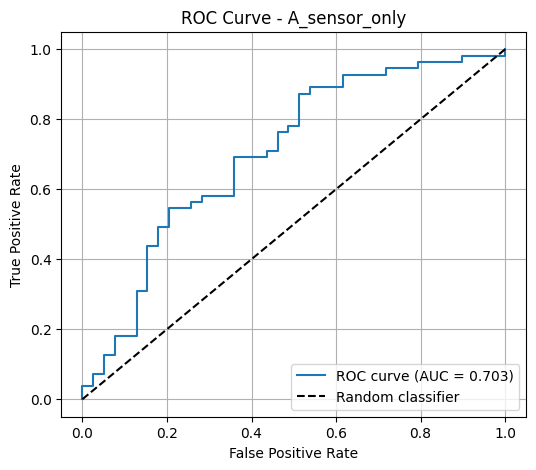


B_QUESTIONNAIRE_ONLY Results:
Accuracy: 0.734
ROC-AUC: 0.818
F1: 0.762


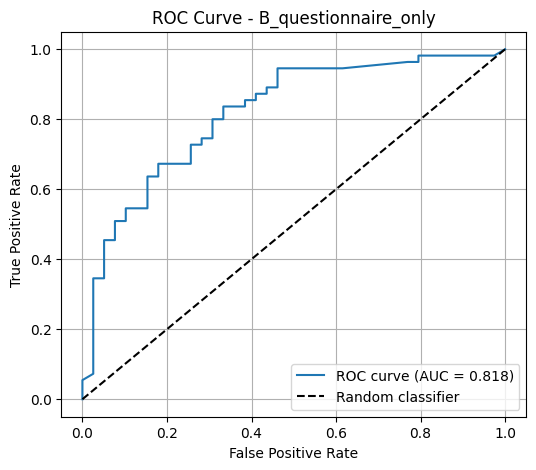


C_ALL_MODALITIES Results:
Accuracy: 0.819
ROC-AUC: 0.891
F1: 0.835


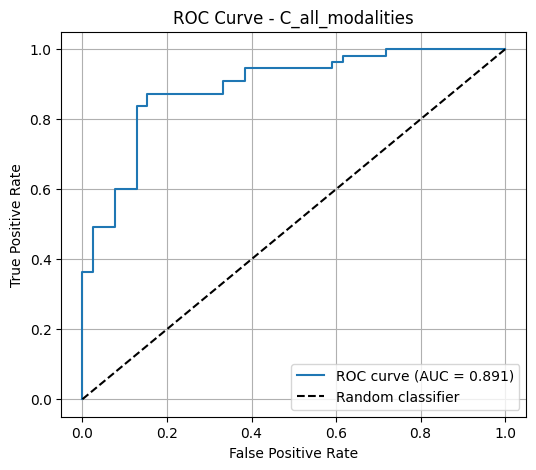

In [36]:
# Evaluate models on test set
results = {}
for setup, model in models.items():
    X_test = setups[setup]['X_test']
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results[setup] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }
    
    print(f"\n{setup.upper()} Results:")
    print(f"Accuracy: {results[setup]['accuracy']:.3f}")
    print(f"ROC-AUC: {results[setup]['roc_auc']:.3f}")
    print(f"F1: {results[setup]['f1']:.3f}")

    # Plot ROC curve for the current setup
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {results[setup]["roc_auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {setup}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

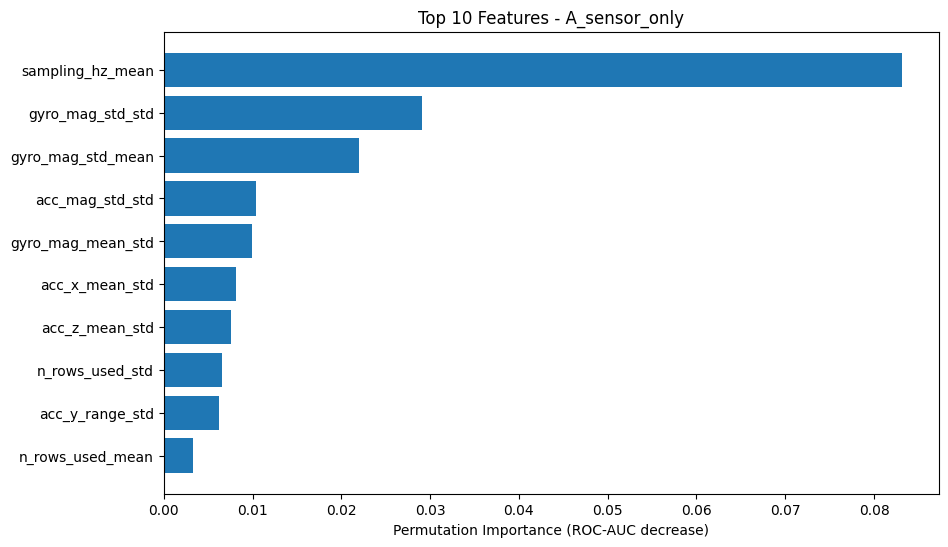


Top 5 features for A_sensor_only:
              feature  importance_mean  importance_std
0    sampling_hz_mean         0.083124        0.030815
1    gyro_mag_std_std         0.029044        0.011125
9   gyro_mag_std_mean         0.022005        0.010720
23    acc_mag_std_std         0.010443        0.006728
24  gyro_mag_mean_std         0.009930        0.007890


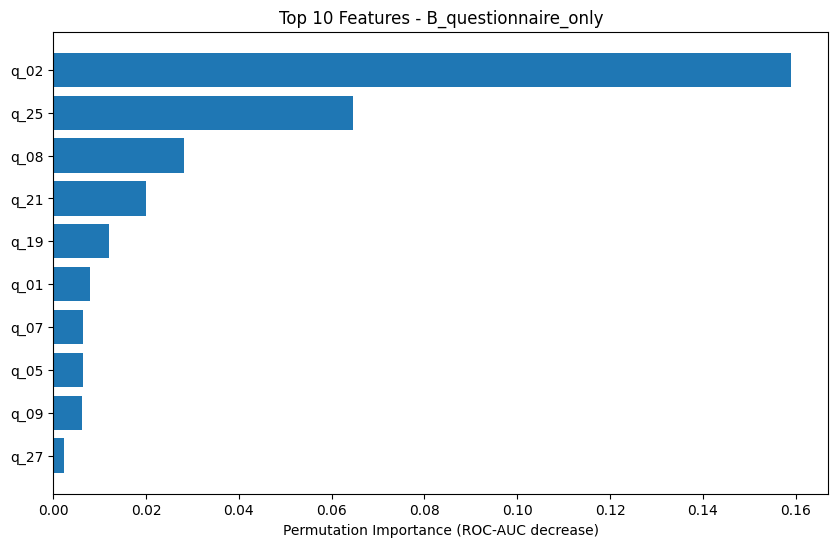


Top 5 features for B_questionnaire_only:
   feature  importance_mean  importance_std
0     q_02         0.159114        0.042637
4     q_25         0.064662        0.026500
1     q_08         0.028205        0.013834
21    q_21         0.020000        0.015428
7     q_19         0.011935        0.004029


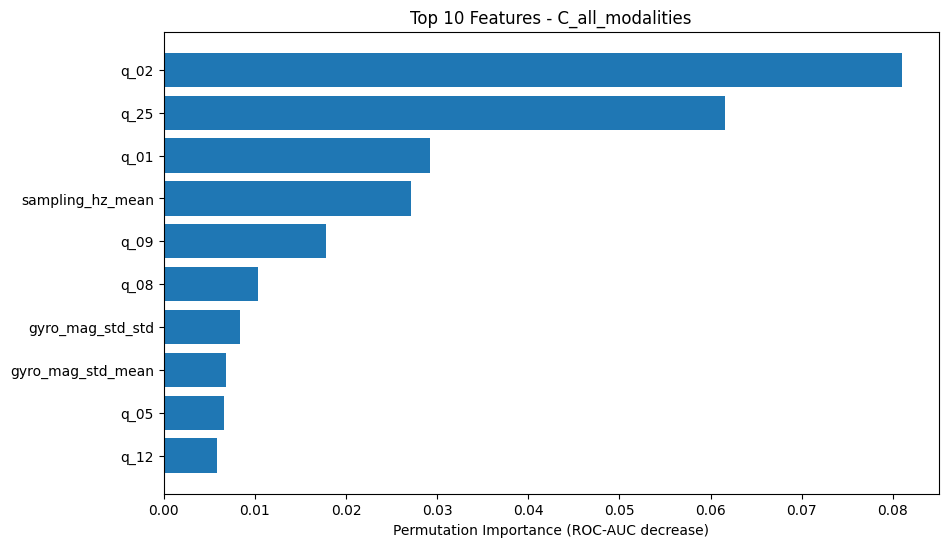


Top 5 features for C_all_modalities:
             feature  importance_mean  importance_std
12              q_02         0.080979        0.029388
16              q_25         0.061538        0.017977
17              q_01         0.029231        0.016550
0   sampling_hz_mean         0.027086        0.012104
15              q_09         0.017786        0.004973


In [37]:
# Permutation importance for feature interpretability
for setup, model in models.items():
    X_test = setups[setup]['X_test']
    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=42, scoring='roc_auc'
    )
    
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': perm_importance.importances_mean,
        'importance_std': perm_importance.importances_std
    }).sort_values('importance_mean', ascending=False)
    
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(10)
    plt.barh(top_features['feature'], top_features['importance_mean'])
    plt.xlabel('Permutation Importance (ROC-AUC decrease)')
    plt.title(f'Top 10 Features - {setup}')
    plt.gca().invert_yaxis()
    plt.show()
    
    print(f"\nTop 5 features for {setup}:")
    print(importance_df.head(5))

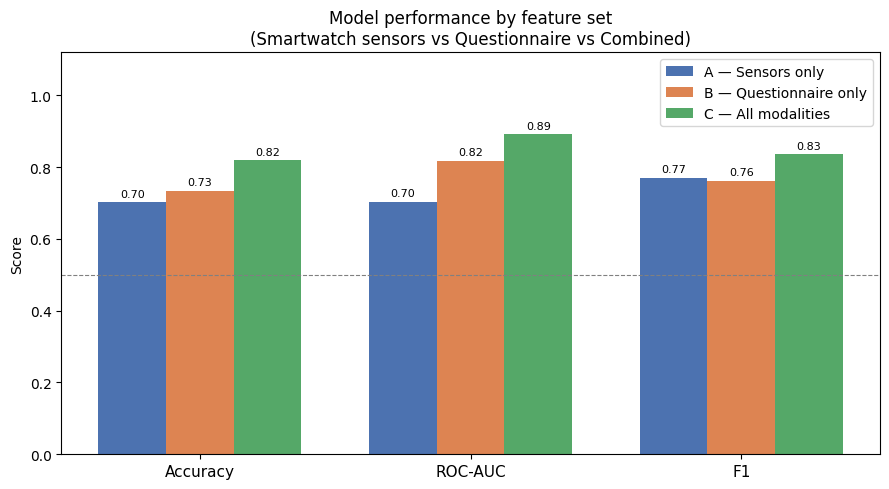

In [38]:
# ── Graphs Multi-metric comparison bar chart ─────────────────────────────

metrics = ['accuracy', 'roc_auc', 'f1']
metric_labels = {'accuracy': 'Accuracy', 'roc_auc': 'ROC-AUC', 'f1': 'F1'}
setup_labels = {
    'A_sensor_only':        'A — Sensors only',
    'B_questionnaire_only': 'B — Questionnaire only',
    'C_all_modalities':     'C — All modalities',
}
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (setup, label) in enumerate(setup_labels.items()):
    values = [results[setup][m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=label, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([metric_labels[m] for m in metrics], fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model performance by feature set\n(Smartwatch sensors vs Questionnaire vs Combined)', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


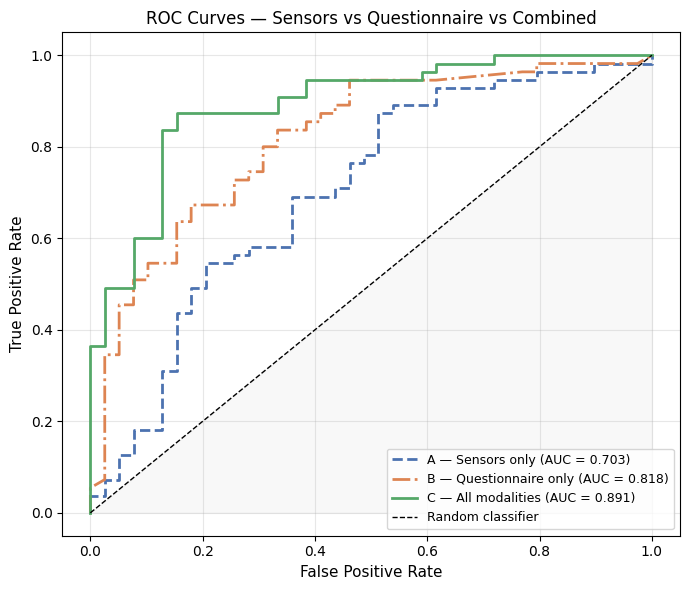

In [39]:
# ── Graph ROC curves overlapped ────────────────────────────────────────

colors_roc = {'A_sensor_only': '#4C72B0', 'B_questionnaire_only': '#DD8452', 'C_all_modalities': '#55A868'}
linestyles = {'A_sensor_only': '--', 'B_questionnaire_only': '-.', 'C_all_modalities': '-'}

fig, ax = plt.subplots(figsize=(7, 6))
for setup, model in models.items():
    X_te = setups[setup]['X_test']
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr_s, tpr_s, _ = roc_curve(y_test, y_prob)
    auc_val = results[setup]['roc_auc']
    ax.plot(fpr_s, tpr_s,
            label=f'{setup_labels[setup]} (AUC = {auc_val:.3f})',
            color=colors_roc[setup],
            linestyle=linestyles[setup],
            linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Sensors vs Questionnaire vs Combined', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Fair Comparison: Sensors vs Questionnaires

To improve the comparison, we run two analyses:
1. **Top-k fair comparison (RF)**: same number of features for sensors and questionnaires.
2. **Model benchmark (A vs B)**: same data, different models, to determine whether the gap is model-dependent or modality-dependent.


Fair comparison table (same feature budget):


AUC                            F1            
modality   Questionnaire (B) Sensors (A) Questionnaire (B) Sensors (A)
k_features                                                            
3                      0.809       0.641             0.789       0.732
5                      0.839       0.678             0.828       0.702
10                     0.828       0.664             0.750       0.729
15                     0.777       0.657             0.725       0.707
20                     0.830       0.680             0.752       0.718
25                     0.818       0.703             0.762       0.770

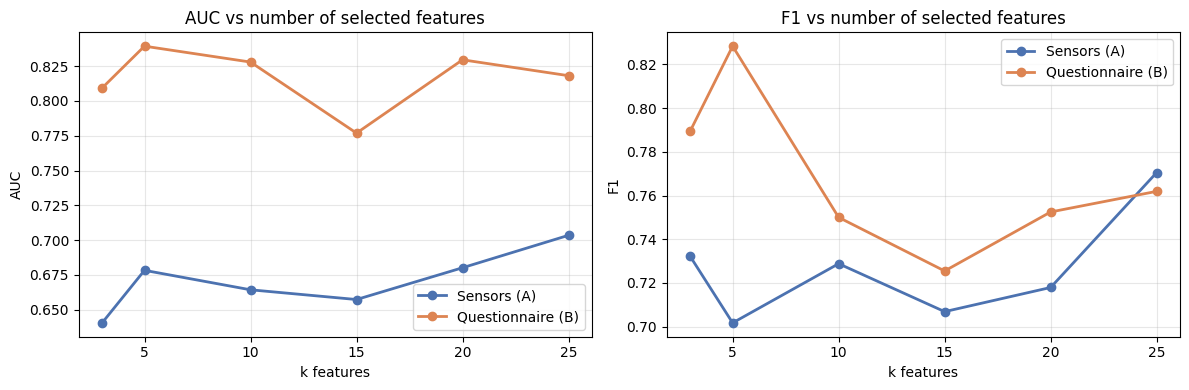

In [40]:
# 1) Top-k fair comparison (same feature budget) with RandomForest
# Compare A (sensors) vs B (questionnaires) using the same number of features k.

feat_A = pd.read_csv(final_dir / 'final_feature_list_A_sensor_only_no_demo_objective.csv')['feature'].tolist()
feat_B = pd.read_csv(final_dir / 'final_feature_list_B_questionnaire_only_no_demo_objective.csv')['feature'].tolist()

k_values = [3, 5, 10, 15, 20, 25]
fair_rows = []

for k in k_values:
    cols_A = feat_A[:k]
    cols_B = feat_B[:k]

    # Use setup-specific optimized parameters for A and B
    rf_A = RandomForestClassifier(**best_params['A_sensor_only'], random_state=42, n_jobs=-1)
    rf_B = RandomForestClassifier(**best_params['B_questionnaire_only'], random_state=42, n_jobs=-1)

    rf_A.fit(setups['A_sensor_only']['X_train'][cols_A], y_train)
    rf_B.fit(setups['B_questionnaire_only']['X_train'][cols_B], y_train)

    pred_A = rf_A.predict(setups['A_sensor_only']['X_test'][cols_A])
    pred_B = rf_B.predict(setups['B_questionnaire_only']['X_test'][cols_B])
    proba_A = rf_A.predict_proba(setups['A_sensor_only']['X_test'][cols_A])[:, 1]
    proba_B = rf_B.predict_proba(setups['B_questionnaire_only']['X_test'][cols_B])[:, 1]

    auc_A = roc_auc_score(y_test, proba_A)
    auc_B = roc_auc_score(y_test, proba_B)
    f1_A = f1_score(y_test, pred_A)
    f1_B = f1_score(y_test, pred_B)

    fair_rows.extend([
        {'modality': 'Sensors (A)', 'k_features': k, 'AUC': auc_A, 'F1': f1_A},
        {'modality': 'Questionnaire (B)', 'k_features': k, 'AUC': auc_B, 'F1': f1_B}
    ])

fair_df = pd.DataFrame(fair_rows)
print('Fair comparison table (same feature budget):')
display(fair_df.pivot(index='k_features', columns='modality', values=['AUC', 'F1']).round(3))

# Plot AUC and F1 vs number of selected features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for modality, color in [('Sensors (A)', '#4C72B0'), ('Questionnaire (B)', '#DD8452')]:
    sub = fair_df[fair_df['modality'] == modality]
    axes[0].plot(sub['k_features'], sub['AUC'], marker='o', linewidth=2, color=color, label=modality)
    axes[1].plot(sub['k_features'], sub['F1'], marker='o', linewidth=2, color=color, label=modality)

axes[0].set_title('AUC vs number of selected features')
axes[0].set_xlabel('k features')
axes[0].set_ylabel('AUC')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('F1 vs number of selected features')
axes[1].set_xlabel('k features')
axes[1].set_ylabel('F1')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


Benchmark summary:


,Model,Setup,AUC,F1,Balanced_Accuracy
0,LogReg,Sensors (A),0.744,0.706,0.686
1,LogReg,Questionnaire (B),0.866,0.779,0.798
2,SVM-RBF,Sensors (A),0.778,0.754,0.649
3,SVM-RBF,Questionnaire (B),0.844,0.781,0.757
4,RandomForest,Sensors (A),0.703,0.770,0.671
5,RandomForest,Questionnaire (B),0.872,0.788,0.770
6,GradientBoosting,Sensors (A),0.681,0.750,0.653
7,GradientBoosting,Questionnaire (B),0.839,0.757,0.739


AUC gap by model (Questionnaire - Sensors):


Setup,Sensors (A),Questionnaire (B),Delta_AUC_B_minus_A
Model,,,
GradientBoosting,0.681,0.839,0.158
LogReg,0.744,0.866,0.123
RandomForest,0.703,0.872,0.168
SVM-RBF,0.778,0.844,0.067


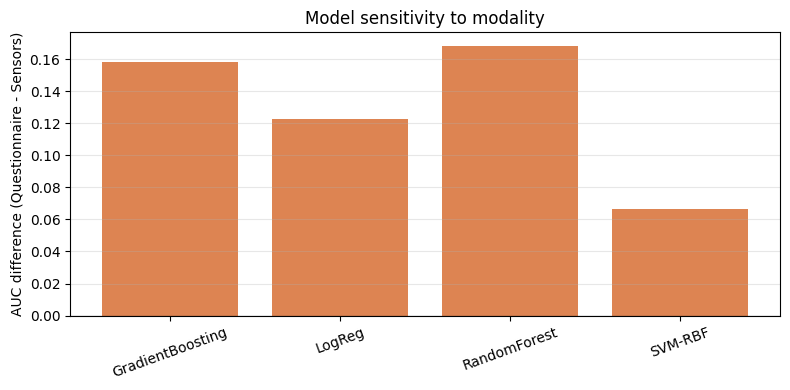

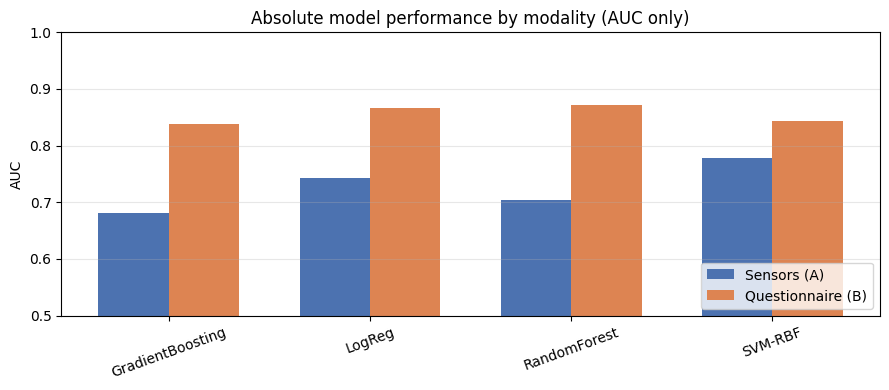

In [41]:
# 2) Model-level benchmark for A (sensors) and B (questionnaires)

model_bank = {
    'LogReg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
    ]),
    'SVM-RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(**best_params['A_sensor_only'], random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

benchmark_rows = []

for model_name, model_obj in model_bank.items():
    # Sensors only (A)
    Xtr_A = setups['A_sensor_only']['X_train']
    Xte_A = setups['A_sensor_only']['X_test']
    model_obj.fit(Xtr_A, y_train)
    pred_A = model_obj.predict(Xte_A)
    prob_A = model_obj.predict_proba(Xte_A)[:, 1]

    benchmark_rows.append({
        'Model': model_name,
        'Setup': 'Sensors (A)',
        'AUC': roc_auc_score(y_test, prob_A),
        'F1': f1_score(y_test, pred_A),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, pred_A)
    })

    # Questionnaire only (B)
    Xtr_B = setups['B_questionnaire_only']['X_train']
    Xte_B = setups['B_questionnaire_only']['X_test']
    model_obj.fit(Xtr_B, y_train)
    pred_B = model_obj.predict(Xte_B)
    prob_B = model_obj.predict_proba(Xte_B)[:, 1]

    benchmark_rows.append({
        'Model': model_name,
        'Setup': 'Questionnaire (B)',
        'AUC': roc_auc_score(y_test, prob_B),
        'F1': f1_score(y_test, pred_B),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, pred_B)
    })

benchmark_df = pd.DataFrame(benchmark_rows)
print('Benchmark summary:')
display(benchmark_df.round(3))

# AUC delta (B - A) by model
pivot_auc = benchmark_df.pivot(index='Model', columns='Setup', values='AUC')
pivot_auc['Delta_AUC_B_minus_A'] = pivot_auc['Questionnaire (B)'] - pivot_auc['Sensors (A)']
print('AUC gap by model (Questionnaire - Sensors):')
display(pivot_auc[['Sensors (A)', 'Questionnaire (B)', 'Delta_AUC_B_minus_A']].round(3))

# Plot 1: model sensitivity (gap)
plt.figure(figsize=(8, 4))
colors = ['#DD8452' if v >= 0 else '#4C72B0' for v in pivot_auc['Delta_AUC_B_minus_A']]
plt.bar(pivot_auc.index, pivot_auc['Delta_AUC_B_minus_A'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('AUC difference (Questionnaire - Sensors)')
plt.title('Model sensitivity to modality')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: absolute model performance (AUC only)
auc_pivot = benchmark_df.pivot(index='Model', columns='Setup', values='AUC')
auc_pivot = auc_pivot[['Sensors (A)', 'Questionnaire (B)']]

x = np.arange(len(auc_pivot.index))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width / 2, auc_pivot['Sensors (A)'], width, label='Sensors (A)', color='#4C72B0')
plt.bar(x + width / 2, auc_pivot['Questionnaire (B)'], width, label='Questionnaire (B)', color='#DD8452')
plt.xticks(x, auc_pivot.index, rotation=20)
plt.ylim(0.5, 1.0)
plt.ylabel('AUC')
plt.title('Absolute model performance by modality (AUC only)')
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()